(2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  Hou

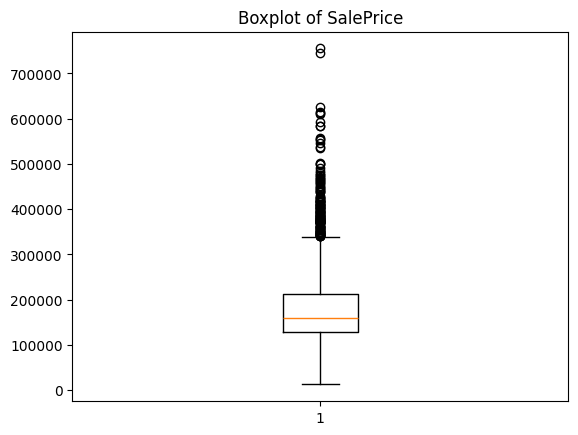

456666.3700000001


In [ ]:
from cleaning01 import clean_data
df = clean_data()

## Phase 3: Exploratory Data Analysis


### Task 1: Histograms
The histograms show that SalePrice and Gr Liv Area are right-skewed, where most values are in the lower range and only a few are very high. Overall Qual is discrete and mostly falls in the medium to high levels. This means that high values are rare and might affect the analysis, so a transformation may be needed.

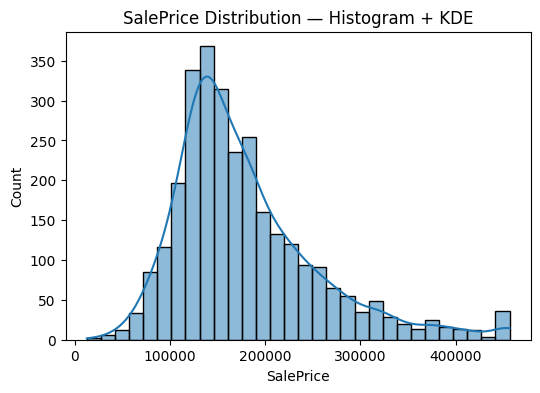

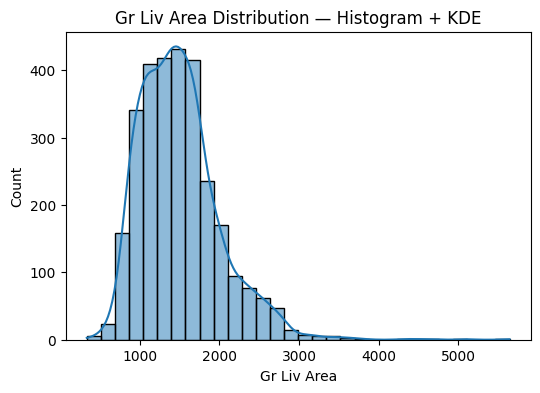

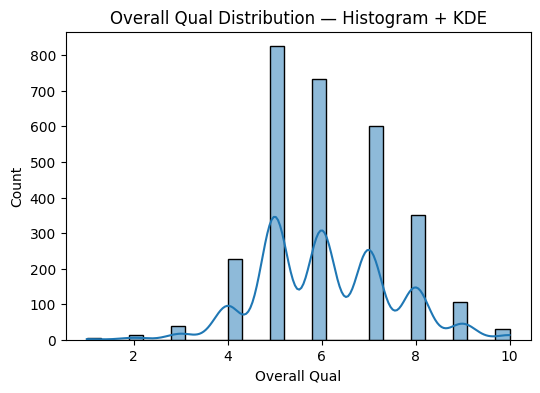

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms(df):
    cols = ["SalePrice", "Gr Liv Area", "Overall Qual"]
    for col in cols:
      plt.figure(figsize=(6,4))
      sns.histplot(df[col], bins=30, edgecolor="black", kde=True)
      plt.title(f"{col} Distribution — Histogram + KDE")
      plt.xlabel(col)
      plt.ylabel("Count")
      plt.show()
plot_histograms(df)

###Task 2: Boxplot
The boxplot shows that SalePrice increases as Overall Quality increases, where prices clearly go up with higher quality. However, Overall Condition has a weaker and less clear relationship with price. This means that quality affects house prices more than condition.

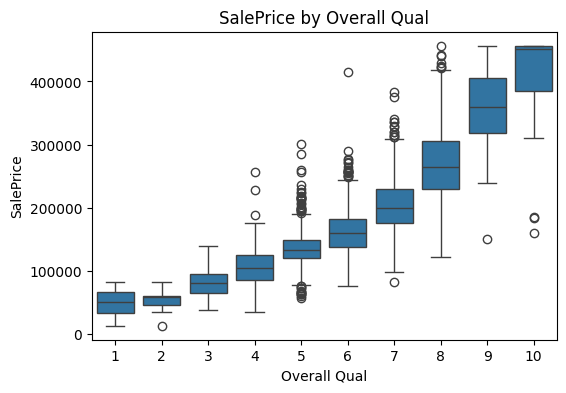

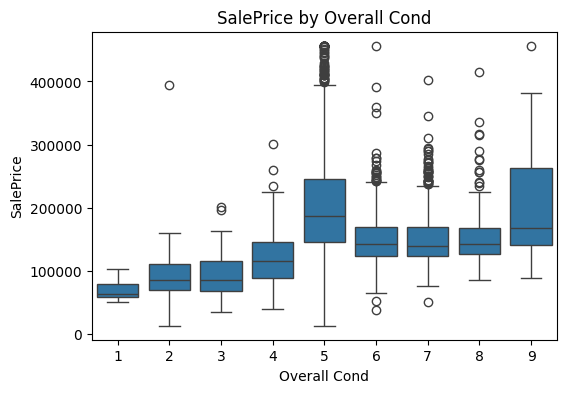

In [ ]:
def plot_boxplots(df):
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Overall Qual", y="SalePrice", data=df)
    plt.title("SalePrice by Overall Qual")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Overall Cond", y="SalePrice", data=df)
    plt.title("SalePrice by Overall Cond")
    plt.show()
plot_boxplots(df)

###Task 3: Heatmap
The heatmap shows relationships between multiple features, with Overall Quality and Gr Liv Area having the highest correlation with SalePrice. Other variables display weaker correlations in comparison. This indicates that size and quality are the most important factors influencing house prices.

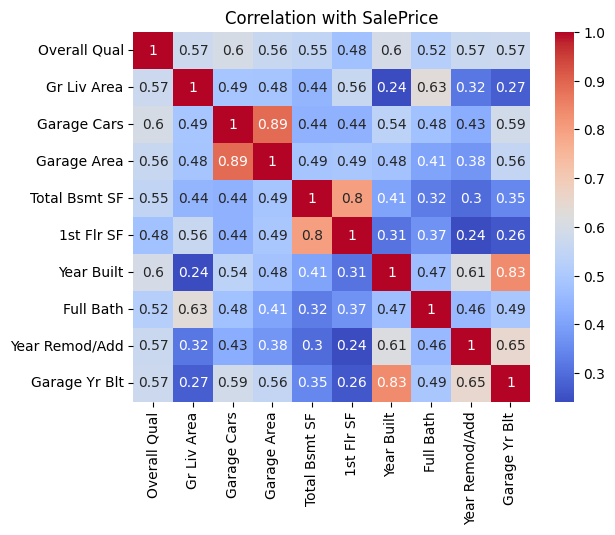

In [ ]:
def plot_heatmap(df):
    corr = df.select_dtypes(include="number").corr()
    top = corr["SalePrice"].abs().sort_values(ascending=False).drop("SalePrice").head(10)
    corr_top = df[top.index].corr()
    sns.heatmap(corr_top, annot=True, cmap="coolwarm")
    plt.title("Correlation with SalePrice")
    plt.show()
plot_heatmap(df)

### Task 4: Scatter Plot
The scatter plot shows a positive relationship between Gr Liv Area and SalePrice, where larger houses tend to have higher prices. The color variation indicates that higher-quality houses also achieve higher prices. This suggests that both size and quality together influence house value.

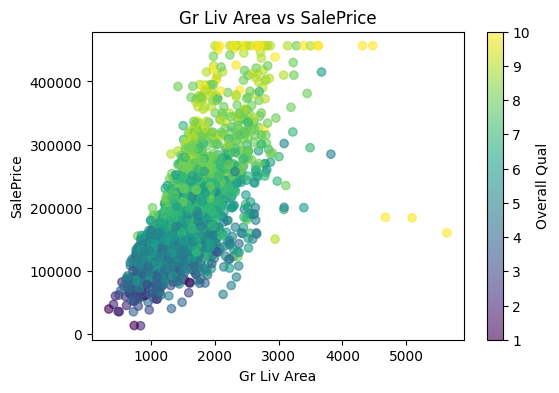

In [ ]:
def plot_scatter(df):
    plt.figure(figsize=(6,4))
    plt.scatter(df["Gr Liv Area"], df["SalePrice"],
                c=df["Overall Qual"], cmap="viridis", alpha=0.6)
    plt.colorbar(label="Overall Qual")
    plt.title("Gr Liv Area vs SalePrice")
    plt.xlabel("Gr Liv Area")
    plt.ylabel("SalePrice")
    plt.show()
plot_scatter(df)

### Task 5: Groupby Summary
The groupby analysis shows that the average SalePrice increases steadily with Overall Quality levels. High-quality houses have the highest average prices, while low-quality houses have the lowest. This confirms that quality is a key factor influencing house prices.

In [ ]:
def groupby_analysis(df):
    result = df.groupby("Overall Qual")["SalePrice"].mean()
    print("Highest:", result.idxmax())
    print("Lowest:", result.idxmin())
groupby_analysis(df)

Highest: 10
Lowest: 1


## Math Basics


### Task 1: Mean and Standard Deviation
I calculated the mean and standard deviation of SalePrice manually using NumPy to understand its central tendency and variability.

In [ ]:
import numpy as np
def compute_mean_std(df):
    data = df["SalePrice"].values
    mean = np.sum(data) / len(data)
    variance = np.sum((data - mean) ** 2) / len(data)
    std = np.sqrt(variance)
    print("Mean", mean)
    print("Standard Deviation", std)

compute_mean_std(df)

Mean 179956.70481228668
Standard Deviation 76061.61121141634


### Task 2: Standardization
The manually standardized values are almost identical to the StandardScaler output, confirming correctness.

In [ ]:
from sklearn.preprocessing import StandardScaler
def standardize_feature(df, col):
    data = df[[col]].values
    mean = np.sum(data) / len(data)
    std = np.sqrt(np.sum((data - mean) ** 2) / len(data))
    manual_z = (data - mean) / std
    sklearn_z = StandardScaler().fit_transform(data)
    print(manual_z[:5])
    print(sklearn_z[:5])
    return manual_z
standardize_feature(df, "Gr Liv Area")

[[ 0.30926506]
 [-1.19442705]
 [-0.33771825]
 [ 1.20752324]
 [ 0.25584442]]
[[ 0.30926506]
 [-1.19442705]
 [-0.33771825]
 [ 1.20752324]
 [ 0.25584442]]


array([[ 0.30926506],
       [-1.19442705],
       [-0.33771825],
       ...,
       [-1.04801492],
       [-0.21900572],
       [ 0.9898836 ]])

### Task 3: Cosine Similarity
I calculated cosine similarity between the highest and lowest SalePrice houses using numeric features.

In [ ]:
def cosine_similarity(df):
    numeric_df = df.select_dtypes(include=["number"])
    highest = numeric_df.loc[df["SalePrice"].idxmax()]
    lowest = numeric_df.loc[df["SalePrice"].idxmin()]
    a = highest.values
    b = lowest.values
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    cosine_sim = dot_product / (norm_a * norm_b)
    print("Cosine Similarity:", cosine_sim)
cosine_similarity(df)

Cosine Similarity: 0.9999996328852507


### Task 4: Probability
I calculated the probability that high-quality houses (≥7) have prices above the average.

In [ ]:
def compute_probability(df):
    threshold = df["SalePrice"].mean()
    high_quality = df[df["Overall Qual"] >= 7]
    high_price = high_quality["SalePrice"] > threshold
    probability = high_price.mean()
    print( probability)
compute_probability(df)

0.8247706422018348


#Final Step: Create eda() Function



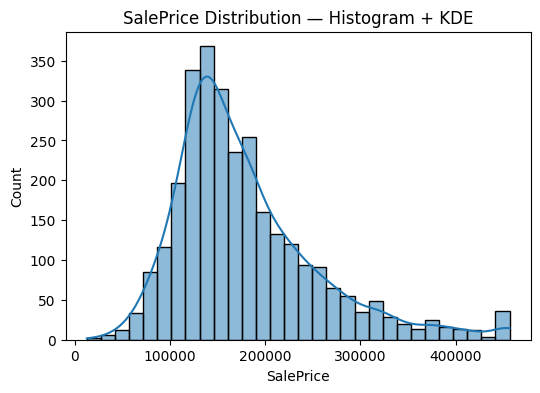

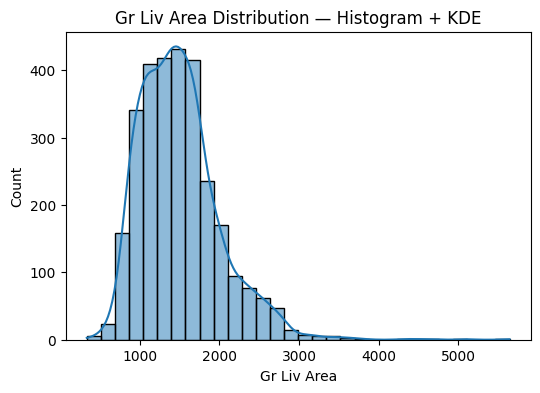

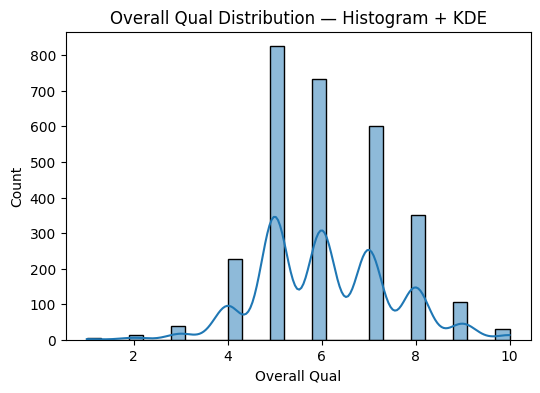

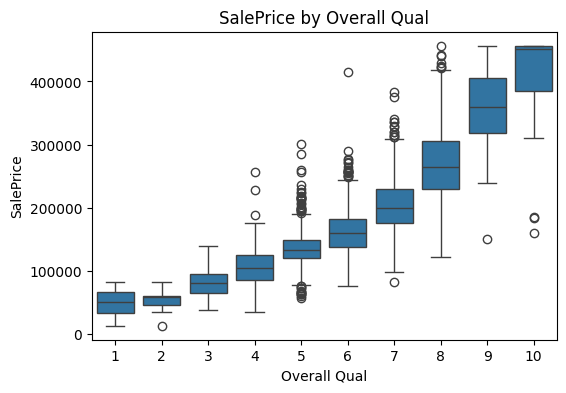

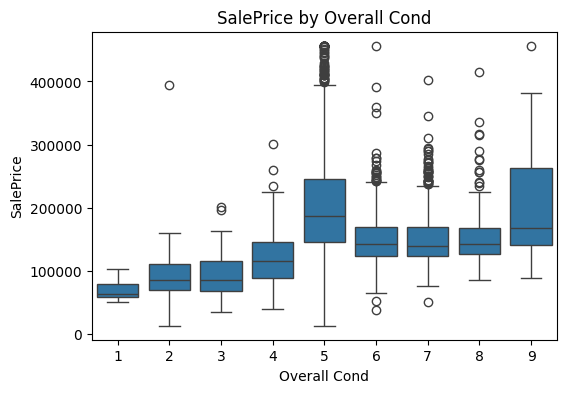

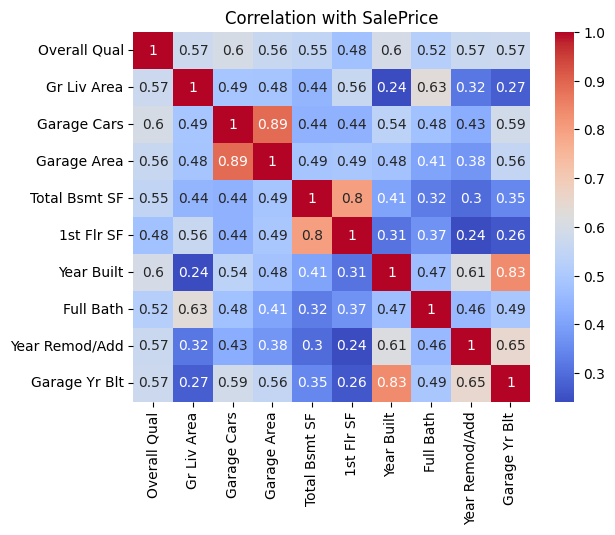

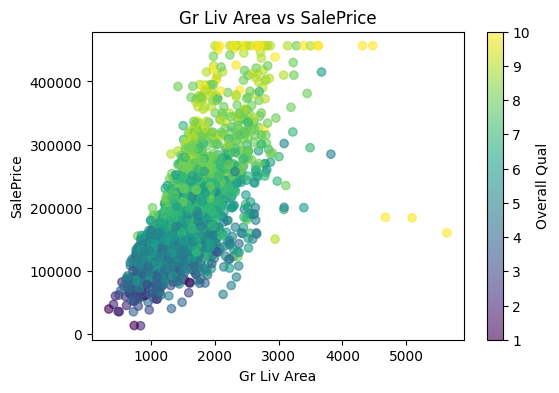

Highest: 10
Lowest: 1
Mean 179956.70481228668
Standard Deviation 76061.61121141634
[[ 0.30926506]
 [-1.19442705]
 [-0.33771825]
 [ 1.20752324]
 [ 0.25584442]]
[[ 0.30926506]
 [-1.19442705]
 [-0.33771825]
 [ 1.20752324]
 [ 0.25584442]]
Cosine Similarity: 0.9999996328852507
0.8247706422018348


In [ ]:
def run_eda(df):
    plot_histograms(df)
    plot_boxplots(df)
    plot_heatmap(df)
    plot_scatter(df)
    groupby_analysis(df)
    compute_mean_std(df)
    standardize_feature(df, "Gr Liv Area")
    cosine_similarity(df)
    compute_probability(df)
run_eda(df)
